# Lab 2: Geostrophic Adjustment

**Driving question:** How does geostrophic balance get established from some initial disturbance, and what governs the nature of this *geostrophic adjustment*?

**Your task:** This notebook already contains a complete model that simulates geostrophic adjustment and horizontal propagating shallow water waves by numerically solving (i.e., integrating) the linearized shallow water equations. Your job is to:
1. Use this model to run experiments by modifying key parameters
2. Create visuals that help you demonstrate the sensitivities of geostrophic adjustment to those changes
3. Write up interpretations in markdown boxes at the bottom of this notebook.

More below on each of these tasks...

**Due date:** complete this notebook and push it to your repo by 11:59 PM, Friday Sept. 18th.

## Model overview

This model numerically solves the shallow water equations of motion for a one-dimensional disturbance on an $f$-plane. Wave propagation and divergent motion manifest in the $x$-dimension. The $v$-wind oscillates through Coriolis deflection, but with no divergence. In this sense, there is no propagation in $y$. The model is linearized: we will neglect nonlinear advection, which significantly simplifies solutions. The equations that the model solves are as follows:

$$
\frac{\partial u}{\partial t}-f_0v=-g\frac{\partial h}{\partial x},
$$

$$
\frac{\partial v}{\partial t}+f_0u=0,
$$

$$
\frac{\partial h}{\partial t}+H\frac{\partial u}{\partial x}=0.
$$

As in class, $u$ and $v$ are the perturbation velocity components, $h$ is the perturbation layer height, $H$ is the base state layer depth, $f_0$ is the Coriolis parameter, and $g$ is gravity.

To kick off disturbances, the model is initialized with an initial Gaussian height anomaly and resting initial-state velocity:

$$
h(0,x)=h_0\exp\left[-\frac{x^2}{2L_0^2}\right],
\quad u(0,x)=v(0,x)=0.
$$

This initial height perturbation requires two input parameters:
1. $L_0$ assumed horizontal length scale (i.e., Gaussian width)
2. $h_0$ amplitude

## Model parameters that can remain unmodified

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Note: most settings below are just the default values.
# Many can be overridden when the model is called further down the notebook.

# Physical constants
G = 9.81                         # m s^-2
OMEGA = 7.2921159e-5             # Earth's rotation rate, s^-1
H = 250.0                        # base state layer depth, m

# Spatial grid
DOMAIN_LENGTH = 20_000_000.0     # 20,000 km
NX = 1000                        # Number of grid points
DX = DOMAIN_LENGTH / NX          # Grid spacing, m
X = (np.arange(NX) - NX // 2) * DX # X-grid, m

# Initial Gaussian disturbance
L_0 = 600_000.0                  # Length scale, i.e., Gaussian width, m
h_0 = 10.0                       # Initial disturbance amplitude, m

# Time integration
DT = 120.0                       # Time step, s
STOP_TIME = 48.0 * 3600.0        # Experiment duration, s
SAVE_EVERY = 5                   # Save output every x time steps

# Print some basic information about the simulation
print(f"Grid spacing: {DX / 1000:.1f} km")
print(f"Grid size: {NX * DX / 1000:.0f} km")
print(f"Experiment duration: {STOP_TIME / 3600:.0f} h")
print(f"Time step: {DT / 60:.1f} min")
print()

# Print some default settings
print(f"Initial disturbance width L_0: {L_0 / 1000:.0f} km")
print(f"Initial disturbance amplitude h_0: {h_0} m")

Grid spacing: 20.0 km
Grid size: 20000 km
Experiment duration: 48 h
Time step: 2.0 min

Initial disturbance width L_0: 600 km
Initial disturbance amplitude h_0: 10.0 m


## Model engine

### Support functions

In [2]:
# Calculate the Coriolis parameter f_0
def coriolis_parameter(latitude_degrees):
    latitude_radians = np.deg2rad(latitude_degrees)
    return 2.0 * OMEGA * np.sin(latitude_radians)

# Calculate the x-gradient using a second-order centered difference scheme
# with periodic boundary conditions
def centered_gradient(field, dx=DX):
    return (np.roll(field, -1, axis=-1) - np.roll(field, 1, axis=-1)) / (2.0 * dx)

# Initially resting fluid with a centered Gaussian height anomaly
def initial_conditions(amplitude=h_0, width=L_0, x=X):
    h = amplitude * np.exp(-0.5 * (x / width) ** 2)
    u = np.zeros_like(h)
    v = np.zeros_like(h)
    return u, v, h

### Main driver functions

In [3]:
# Advance the fields to the next time step with a centered half/full/half-step update
def advance_one_step(u0, v0, h0, dt, f_0, g=G, mean_depth=H, dx=DX):

    # This is where our equations of motion are implemented
    # 
    # The centered half/full/half-step update is a numerical integration scheme that
    # updates the velocity and height fields in a staggered manner.
    # 
    # The first half-step updates the velocity fields using the current height field,
    # then the full step updates the height field using the updated velocity fields,
    # and finally, the second half-step updates the velocity fields again using the
    # new height field.
    # 
    # This approach helps maintain numerical stability and accuracy in the solution.

    du_dt = f_0 * v0 - g * centered_gradient(h0, dx)
    u_half = u0 + 0.5 * dt * du_dt

    dv_dt = -f_0 * u_half
    dh_dt = -mean_depth * centered_gradient(u_half, dx)

    v1 = v0 + dt * dv_dt
    h1 = h0 + dt * dh_dt
    u1 = u_half + 0.5 * dt * (f_0 * v1 - g * centered_gradient(h1, dx))

    return u1, v1, h1

# Integrate one experiment and return a dictionary of saved NumPy arrays
def integrate_case(
    f_0,                   # Coriolis setting (required argument)
    amplitude=h_0,         # Perturbation amplitude (optional argument with a default setting if blank)
    width=L_0,             # Length scale (optional argument)
    stop_time=STOP_TIME,   # Experiment duration (optional argument)
    dt=DT,                 # Time step (optional argument)
    save_every=SAVE_EVERY, # Save output every x time steps (optional argument)
):
    # The model parameters for a given integration are established by the arguments passed
    # into the function. As the comments above imply, a mix of required and optional
    # arguments are used. Optional arguments are those that have default values provided
    # in the function definition. As written, f_0 is a required input, while all other
    # parameters use default values unless explicitly specified in the function call.

    # Establish model initial state
    u, v, h = initial_conditions(amplitude=amplitude, width=width)

    n_steps = int(round(stop_time / dt))

    # Main model time loop
    # Variables are saved in lists at specified intervals (using the % "modulo" operator)
    times, u_saved, v_saved, h_saved = [], [], [], []
    for step in range(n_steps + 1):
        if step % save_every == 0:
            times.append(step * dt)
            u_saved.append(u.copy())
            v_saved.append(v.copy())
            h_saved.append(h.copy())

        if step < n_steps:
            u, v, h = advance_one_step(u, v, h, dt, f_0)

    # Return a dictionary of saved NumPy arrays and parameter settings
    return {
        "time": np.asarray(times),
        "x": X.copy(),
        "u": np.asarray(u_saved),
        "v": np.asarray(v_saved),
        "h": np.asarray(h_saved),
        "f_0": float(f_0),
        "amplitude": float(amplitude),
        "width": float(width),
    }

## YOUR TASK STARTS HERE

The function `integrate_case()` in the above code block is the main model *driver function.* As in most atmospheric models, the driver is the parent function that calls all other tasks to run the model. In our model, this driver function does the following:
1. Establishes the parameters for the model run
2. Creates the model initial state
3. Loops over time to integrate the equations
4. Writes out the model output as a dictionary

As noted in the comments inside that function, the parameters for a given model run are established through the function's arguments. Only one argument ($f_0$) is required, while all others are set to default values unless specified otherwise when the function is called.

Your task is to run the model for a set of parameter modifications across two key dimensions: $f_0$ and $L_0$ (*width* in the function call). Compare at least four values of $f_0$, including zero, while holding $L_0$ fixed. Separately, compare at least four values of $L_0$ at a fixed, nonzero value of $f_0$. You may reuse a common baseline experiment. Keep track of any parameters you change and hold constant.

Examples of how to run the model by calling this function are provided below. In the loop example, the code populates `lists` and `dictionaries`, which are two distinct powerful ways to store collections of information. See [this page](https://www.geeksforgeeks.org/python/difference-between-list-and-dictionary-in-python/) for a quick overview of their usage and differences.

### Example run code

I suggest leaving this code unchanged for reference, and writing your own in the block below (copying anything that may be helpful from this one).

In [4]:
# Example model run for a given latitude and f_0-setting
# All other settings are left to default values
latitude = 15.0
f_0 = coriolis_parameter(latitude)
single_run_f15deg = integrate_case(f_0)
# Print the dictionary keys and some parameter values
print(single_run_f15deg.keys())
print(f"Coriolis parameter: {single_run_f15deg['f_0']}")
print(f"h_0: {single_run_f15deg['amplitude']}")
print(f"L_0: {single_run_f15deg['width']}")
print()

# Example model run for a given latitude and f_0-setting with a smaller L_0 value
single_run_f15_modL0 = integrate_case(f_0, width=100000.0)
# Print the dictionary keys and some parameter values
print(single_run_f15_modL0.keys())
print(f"Coriolis parameter: {single_run_f15_modL0['f_0']}")
print(f"h_0: {single_run_f15_modL0['amplitude']}")
print(f"L_0: {single_run_f15_modL0['width']}")
print()

# Use a loop to iteratively run a set of 4 experiments and store their parameter settings
case_names = [] # initialize a list
run_params = [] # initialize a list
runs = {} # initialize a dictionary; each new entry has a "key" (e.g., a name)
for lat in [0, 15.0, 35.0, 60.0]:
    f = coriolis_parameter(lat)
    case_label = f"{lat}°N"
    print(f"Integrating {case_label} ...")
    case_names.append(case_label)
    run_params.append({"label": case_label, "latitude": lat, "f_0": f, "amplitude": h_0, "width": L_0})
    runs[case_label] = integrate_case(f, amplitude=h_0, width=L_0)

dict_keys(['time', 'x', 'u', 'v', 'h', 'f_0', 'amplitude', 'width'])
Coriolis parameter: 3.774676948029817e-05
h_0: 10.0
L_0: 600000.0

dict_keys(['time', 'x', 'u', 'v', 'h', 'f_0', 'amplitude', 'width'])
Coriolis parameter: 3.774676948029817e-05
h_0: 10.0
L_0: 100000.0

Integrating 0°N ...
Integrating 15.0°N ...
Integrating 35.0°N ...
Integrating 60.0°N ...


### Your new run code

In [ ]:
# ============================================================
# EXPERIMENT SETUP
# ============================================================
# We perform two separate sensitivity experiments:
#
# 1. Change f0 by changing latitude, while keeping L0 fixed.
# 2. Change L0 while keeping f0 fixed at 35°N.
#
# The 35°N, L0 = 600 km experiment is our common baseline case. 
# The latitude value was chosen in order to properly witness the Coriolis effects
# and the width value

# Latitudes used for the f0 sensitivity experiment
LATITUDES = [0.0, 15.0, 35.0, 60.0]

# Initial disturbance widths used for the L0 sensitivity experiment
WIDTHS_KM = [150, 300, 600, 1200]

# Baseline rotating latitude
BASELINE_LAT = 35.0


# ============================================================
# EXPERIMENT 1: sensitivity to f0
# ============================================================
# L0 and h0 remain fixed at their default values.

runs_f = {}

for lat in LATITUDES:
    
    # Convert latitude into Coriolis parameter
    f_0 = coriolis_parameter(lat)
    
    # Use a clean label such as "35°N"
    label = f"{lat:g}°N"
    
    print(
        f"Integrating {label}: "
        f"f0 = {f_0:.3e} s^-1, "
        f"L0 = {L_0 / 1000:.0f} km"
    )
    
    runs_f[label] = integrate_case(
        f_0,
        amplitude=h_0,
        width=L_0
    )


# ============================================================
# EXPERIMENT 2: sensitivity to L0
# ============================================================
# Here f0 is fixed at 35°N and only the Gaussian width changes.

f_fixed = coriolis_parameter(BASELINE_LAT)

runs_L = {}

for width_km in WIDTHS_KM:
    
    # Convert km -> m because the model uses SI units
    width_m = width_km * 1000.0
    
    label = f"{width_km:g} km"
    
    print(
        f"Integrating L0 = {label}: "
        f"latitude = {BASELINE_LAT:g}°N, "
        f"f0 = {f_fixed:.3e} s^-1"
    )
    
    runs_L[label] = integrate_case(
        f_fixed,
        amplitude=h_0,
        width=width_m
    )


# Define the common baseline experiment for later plots
BASELINE_LABEL = f"{BASELINE_LAT:g}°N"
baseline_run = runs_f[BASELINE_LABEL]

Integrating 0°N: f0 = 0.000e+00 s^-1, L0 = 600 km
Integrating 15°N: f0 = 3.775e-05 s^-1, L0 = 600 km
Integrating 35°N: f0 = 8.365e-05 s^-1, L0 = 600 km
Integrating 60°N: f0 = 1.263e-04 s^-1, L0 = 600 km
Integrating L0 = 150 km: latitude = 35°N, f0 = 8.365e-05 s^-1
Integrating L0 = 300 km: latitude = 35°N, f0 = 8.365e-05 s^-1
Integrating L0 = 600 km: latitude = 35°N, f0 = 8.365e-05 s^-1
Integrating L0 = 1200 km: latitude = 35°N, f0 = 8.365e-05 s^-1


In [ ]:
# ============================================================
# TIME-SELECTION HELPER
# ============================================================
# This avoids hard-coding the fact that each saved timestep is 10 min.
# Six snapshots used to visualize the evolution of one experiment
SNAPSHOT_HOURS = np.array([0, 8, 16, 24, 32, 40])


def nearest_time_indices(run, hours):
    """
    Return the indices of the saved model times closest to the
    requested times in hours.
    """
    
    time_hours = run["time"] / 3600.0
    
    return np.array([
        np.argmin(np.abs(time_hours - hour))
        for hour in hours
    ])


# Check which indices correspond to our requested snapshots
snapshot_indices = nearest_time_indices(
    baseline_run,
    SNAPSHOT_HOURS
)

print("Hours:  ", SNAPSHOT_HOURS)
print("Indices:", snapshot_indices)

Hours:   [ 0  8 16 24 32 40]
Indices: [  0  48  96 144 192 240]


## Plots

The plotting task for this assignment provides a lot of latitude (zing). But your visuals should accomplish the following:
- Provide an adequate sense of how the geostrophic adjustment (GA) process works and evolves in general in this model by showing the evolution of height and both velocity components for a rotating (i.e., $f_0\ne0$) experiment
- Demonstrate how the GA process differs as a function of varied $f_0$ and $L_0$ (it is probably ideal to depict those sensitivities separately).

Also, in all plots, be sure to label axes with units and identify cases (any parameter settings as needed) and times. Use consistent axis limits or color scales where practical when direct comparisons are important.

Here are some example plot ideas, which may be helpful.
- multipanel for a single simulation: a set of snapshots of the perturbation height and wind fields at several times through the duration of a given simulation
- multipanel for multiple simulations: plot a given variable at multiple time steps for a given simulation in each panel
- Hovmöller diagrams (time vs. $x$) with a given perturbation variable shaded, which could be shown as a multipanel for different variables or different simulations (using the same variable)

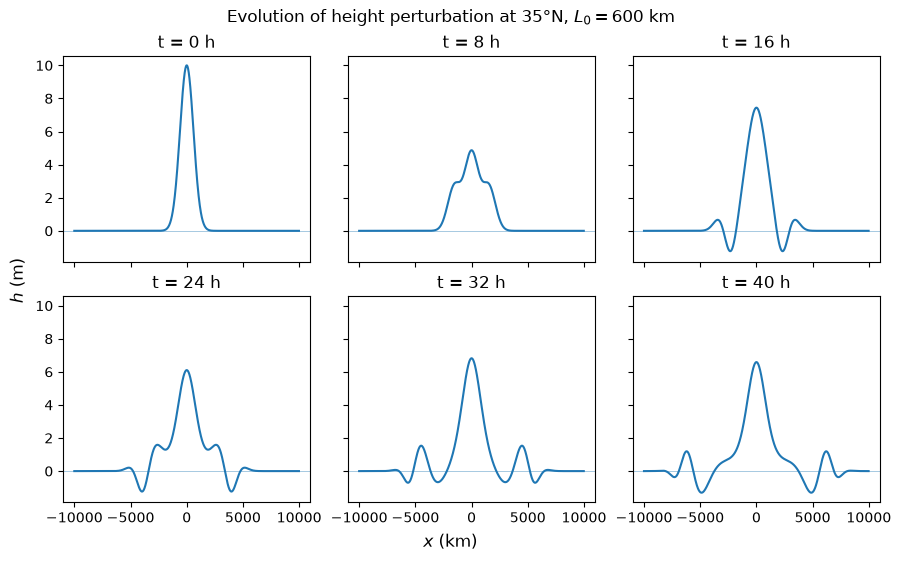

In [75]:
# ============================================================
# ROTATING BASELINE CASE: HEIGHT PERTURBATION
# ============================================================

run = baseline_run

x_km = run["x"] / 1000.0
indices = nearest_time_indices(run, SNAPSHOT_HOURS)

fig, axs = plt.subplots(
    2, 3,
    figsize=(8.9, 5.5),
    sharex=True,
    sharey=True,
    layout="constrained"
)

fig.suptitle(
    rf"Evolution of height perturbation at "
    rf"{BASELINE_LAT:g}°N, "
    rf"$L_0={L_0 / 1000:.0f}$ km"
)

for ax, idx, hour in zip(
    axs.flat,
    indices,
    SNAPSHOT_HOURS
):
    
    ax.plot(
        x_km,
        run["h"][idx, :]
    )
    
    ax.set_title(f"t = {hour:g} h")
    
    # Reference line corresponding to no height perturbation
    ax.axhline(
        0,
        linewidth=0.7,
        alpha=0.4
    )


fig.supxlabel(r"$x$ (km)")
fig.supylabel(r"$h$ (m)")

plt.show()

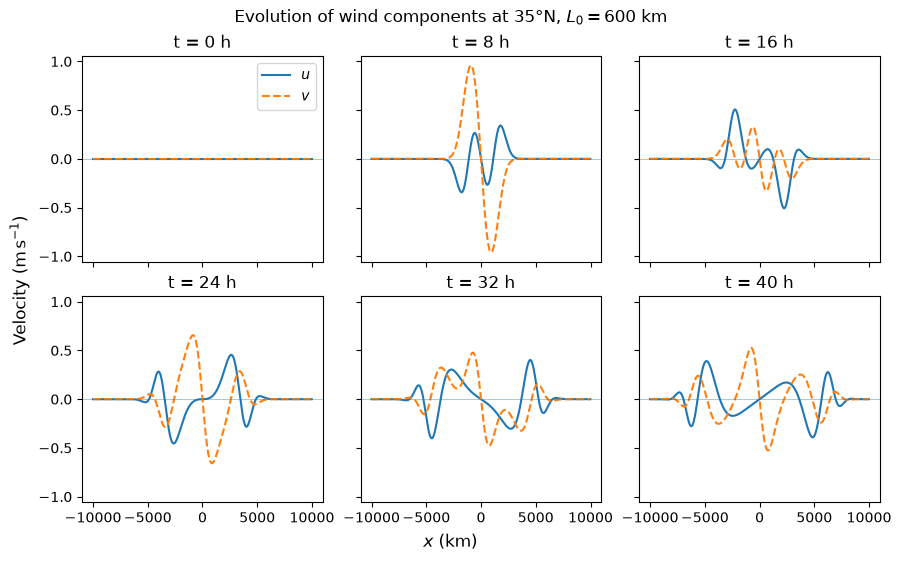

In [ ]:
# ============================================================
# ROTATING BASELINE CASE: WIND COMPONENTS
# ============================================================

run = baseline_run

x_km = run["x"] / 1000.0
indices = nearest_time_indices(run, SNAPSHOT_HOURS)

fig, axs = plt.subplots(
    2, 3,
    figsize=(8.9, 5.5),
    sharex=True,
    sharey=True,
    layout="constrained"
)

fig.suptitle(
    rf"Evolution of wind components at "
    rf"{BASELINE_LAT:g}°N, "
    rf"$L_0={L_0 / 1000:.0f}$ km"
)

for ax, idx, hour in zip(
    axs.flat,
    indices,
    SNAPSHOT_HOURS
):
    
    # Zonal perturbation velocity
    ax.plot(
        x_km,
        run["u"][idx, :],
        label=r"$u$"
    )
    
    # Meridional perturbation velocity
    ax.plot(
        x_km,
        run["v"][idx, :],
        linestyle="--",
        label=r"$v$"
    )
    
    ax.axhline(
        0,
        linewidth=0.7,
        alpha=0.4
    )
    
    ax.set_title(f"t = {hour:g} h")


fig.supxlabel(r"$x$ (km)")
fig.supylabel(r"Velocity ($\mathrm{m\,s^{-1}}$)")

axs[0, 0].legend()

plt.show()

In [80]:
# ============================================================
# HOVMÖLLER PLOT FUNCTION
# ============================================================

# Common height scale for both sensitivity experiments.
all_sensitivity_runs = (
    list(runs_f.values())
    + list(runs_L.values())
)

HEIGHT_VMAX = max(
    np.max(np.abs(run["h"]))
    for run in all_sensitivity_runs
)


def plot_height_hovmoller(cases, title):
    """
    Make a 2x2 set of Hovmöller diagrams of height perturbation.
    
    x-axis: horizontal distance
    y-axis: time
    shading: height perturbation h
    
    All panels use the same color scale.
    """
    
    fig, axs = plt.subplots(
        2, 2,
        figsize=(9, 6),
        sharex=True,
        sharey=True,
        layout="constrained"
    )
    
    # Diverging normalization centered on h = 0
    norm = TwoSlopeNorm(
        vmin=-HEIGHT_VMAX,
        vcenter=0.0,
        vmax=HEIGHT_VMAX
    )
    
    for ax, (label, run) in zip(
        axs.flat,
        cases.items()
    ):
        
        x_km = run["x"] / 1000.0
        time_hours = run["time"] / 3600.0
        
        pcm = ax.pcolormesh(
            x_km,
            time_hours,
            run["h"],
            shading="auto",
            cmap="RdBu_r",
            norm=norm
        )
        
        ax.set_title(label)
    
    
    fig.suptitle(title)
    
    fig.supxlabel(r"$x$ (km)")
    fig.supylabel("Time (h)")
    
    fig.colorbar(
        pcm,
        ax=axs,
        label=r"$h$ (m)"
    )
    
    plt.show()

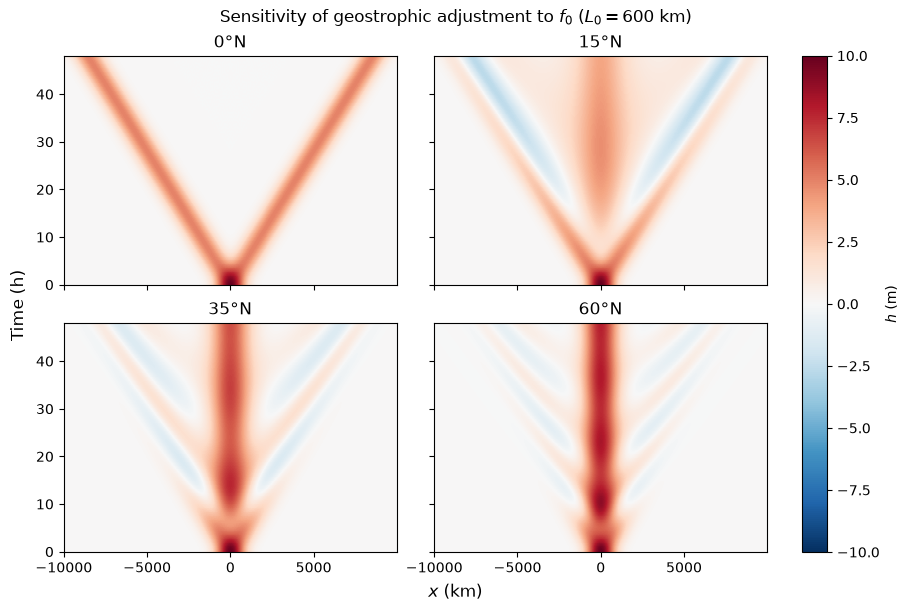

In [81]:
# ============================================================
# HEIGHT RESPONSE TO CHANGING f0
# ============================================================
# L0 = 600 km in every experiment.
# Only the Coriolis parameter changes.

plot_height_hovmoller(
    runs_f,
    title=(
        rf"Sensitivity of geostrophic adjustment to $f_0$ "
        rf"($L_0={L_0 / 1000:.0f}$ km)"
    )
)

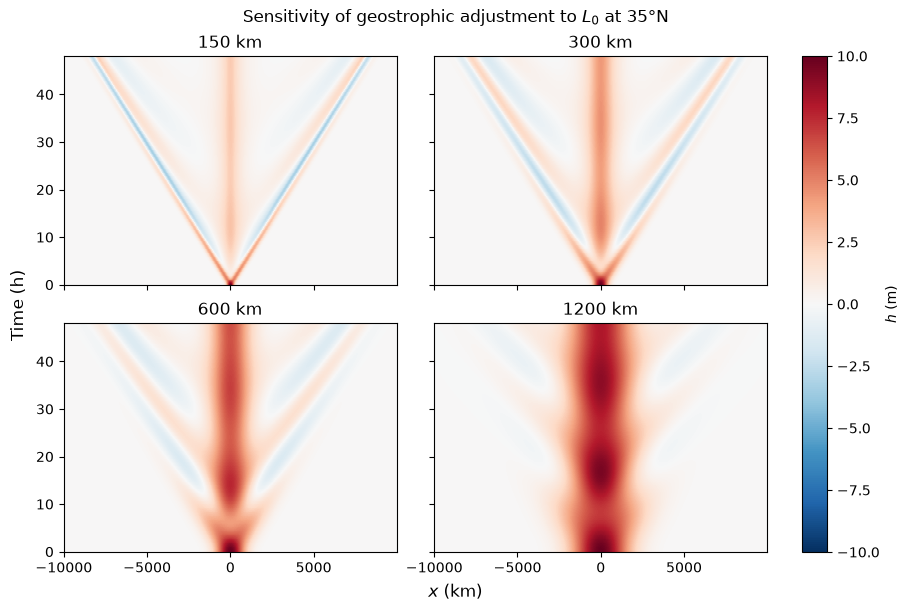

In [82]:
# ============================================================
# HEIGHT RESPONSE TO CHANGING L0
# ============================================================
# f0 is the same in every experiment: its value at 35°N.

plot_height_hovmoller(
    runs_L,
    title=(
        rf"Sensitivity of geostrophic adjustment to $L_0$ "
        rf"at {BASELINE_LAT:g}°N"
    )
)

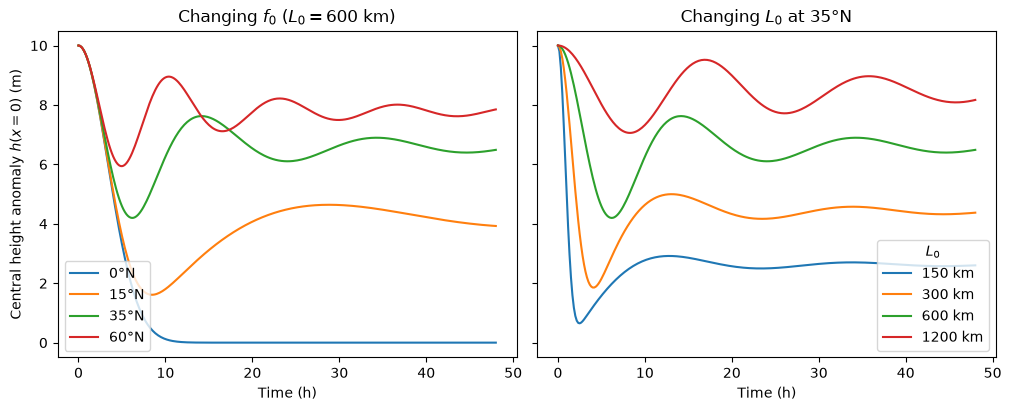

In [83]:
# ============================================================
# EVOLUTION OF THE CENTRAL HEIGHT ANOMALY
# ============================================================

fig, axs = plt.subplots(
    1, 2,
    figsize=(10, 4),
    sharex=True,
    sharey=True,
    layout="constrained"
)


# ------------------------------------------------------------
# Left panel: vary f0
# ------------------------------------------------------------

for label, run in runs_f.items():
    
    # Grid point closest to x = 0
    center_idx = np.argmin(
        np.abs(run["x"])
    )
    
    time_hours = run["time"] / 3600.0
    
    axs[0].plot(
        time_hours,
        run["h"][:, center_idx],
        label=label
    )


axs[0].set_title(
    rf"Changing $f_0$ "
    rf"($L_0={L_0 / 1000:.0f}$ km)"
)

axs[0].set_xlabel("Time (h)")
axs[0].set_ylabel(r"Central height anomaly $h(x=0)$ (m)")
axs[0].legend()


# ------------------------------------------------------------
# Right panel: vary L0
# ------------------------------------------------------------

for label, run in runs_L.items():
    
    center_idx = np.argmin(
        np.abs(run["x"])
    )
    
    time_hours = run["time"] / 3600.0
    
    axs[1].plot(
        time_hours,
        run["h"][:, center_idx],
        label=label
    )


axs[1].set_title(
    rf"Changing $L_0$ at {BASELINE_LAT:g}°N"
)

axs[1].set_xlabel("Time (h)")
axs[1].legend(title=r"$L_0$")

plt.show()

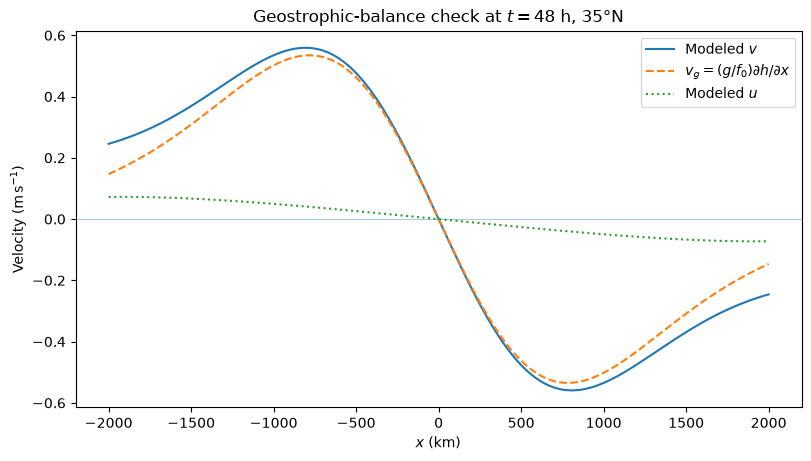

Correlation between v and vg: 0.9963
RMSE(v - vg): 0.0481 m/s
Maximum |u| in central region: 0.0726 m/s


In [84]:
# ============================================================
# GEOSTROPHIC-BALANCE CHECK FOR THE BASELINE CASE
# ============================================================

run = baseline_run

# Use the final model time
balance_hour = 48.0

idx = nearest_time_indices(
    run,
    [balance_hour]
)[0]

x = run["x"]
x_km = x / 1000.0

h_final = run["h"][idx, :]
u_final = run["u"][idx, :]
v_final = run["v"][idx, :]

f_0 = run["f_0"]


# ------------------------------------------------------------
# Calculate the geostrophic v-wind predicted from h
#
# From:
#       f0 * v = g * dh/dx
#
# therefore:
#       vg = (g/f0) * dh/dx
# ------------------------------------------------------------

dh_dx = centered_gradient(h_final)

v_geostrophic = (
    G / f_0
) * dh_dx


# Focus the diagnostic on the central remnant.
# The outward waves are intentionally excluded.
central_mask = np.abs(x) <= 2_000_000.0  # ±2000 km


fig, ax = plt.subplots(
    figsize=(8, 4.5),
    layout="constrained"
)

# Actual modeled meridional velocity
ax.plot(
    x_km[central_mask],
    v_final[central_mask],
    label=r"Modeled $v$"
)

# Meridional velocity expected from geostrophic balance
ax.plot(
    x_km[central_mask],
    v_geostrophic[central_mask],
    linestyle="--",
    label=r"$v_g=(g/f_0)\partial h/\partial x$"
)

# The remaining divergent u-flow
ax.plot(
    x_km[central_mask],
    u_final[central_mask],
    linestyle=":",
    label=r"Modeled $u$"
)

ax.axhline(
    0,
    linewidth=0.7,
    alpha=0.4
)

ax.set_xlabel(r"$x$ (km)")
ax.set_ylabel(r"Velocity ($\mathrm{m\,s^{-1}}$)")

ax.set_title(
    rf"Geostrophic-balance check at "
    rf"$t={balance_hour:g}$ h, "
    rf"{BASELINE_LAT:g}°N"
)

ax.legend()

plt.show()


# ============================================================
# QUANTITATIVE CHECK
# ============================================================

# Correlation between modeled v and geostrophic v
correlation = np.corrcoef(
    v_final[central_mask],
    v_geostrophic[central_mask]
)[0, 1]

# Difference between modeled v and theoretical geostrophic v
rmse = np.sqrt(
    np.mean(
        (
            v_final[central_mask]
            - v_geostrophic[central_mask]
        )**2
    )
)

# Remaining magnitude of the divergent u component
max_abs_u = np.max(
    np.abs(u_final[central_mask])
)

print(
    f"Correlation between v and vg: {correlation:.4f}"
)

print(
    f"RMSE(v - vg): {rmse:.4f} m/s"
)

print(
    f"Maximum |u| in central region: "
    f"{max_abs_u:.4f} m/s"
)

## Diagnostics

For each experiment, diagnose numerical values of $L_D$, $Bu$, and $Ro$ in a table or clearly labeled output. These will be useful for your interpretations below.
$$
L_D=\frac{\sqrt{gH}}{|f_0|},\qquad
Bu=\left(\frac{L_D}{L_0}\right)^2,\qquad
Ro=\frac{U}{|f_0|L_0},\qquad
U=\max_{x,t}\sqrt{u^2+v^2}.
$$
where $U$ is the maximum modeled speed over all saved positions and times; use consistent units in the calculations and be sure to label any units used as needed. Note that some of these metrics are invalid for $f_0=0$ (you can report NaN for those).

In [85]:
# ============================================================
# REQUIRED DYNAMICAL DIAGNOSTICS
# ============================================================

def calculate_diagnostics(run):
    """
    Calculate the dynamical scales requested in the assignment.

    Returns
    -------
    f0
        Coriolis parameter [s^-1]

    L0
        Initial Gaussian width [km]

    U
        Maximum modeled horizontal wind speed [m/s]

    LD
        Rossby deformation radius [km]

    Bu
        Burger number [-]

    Ro
        Rossby number [-]

    h_center_final
        Final perturbation height at x = 0 [m].
        This last quantity is not required explicitly, but is
        useful for comparing the adjusted central remnants.
    """
    
    f = abs(run["f_0"])
    L0 = run["width"]
    
    
    # --------------------------------------------------------
    # Maximum modeled horizontal wind speed
    #
    # U = max sqrt(u^2 + v^2)
    # --------------------------------------------------------
    
    speed = np.sqrt(
        run["u"]**2
        + run["v"]**2
    )
    
    U = np.max(speed)
    
    
    # --------------------------------------------------------
    # Height anomaly remaining at the center at t = 48 h
    # --------------------------------------------------------
    
    center_idx = np.argmin(
        np.abs(run["x"])
    )
    
    h_center_final = run["h"][
        -1,
        center_idx
    ]
    
    
    # --------------------------------------------------------
    # f0 = 0 case
    #
    # LD, Bu and Ro contain division by f0, so these quantities
    # are undefined for the nonrotating experiment.
    # --------------------------------------------------------
    
    if f == 0.0:
        
        LD = np.nan
        Bu = np.nan
        Ro = np.nan
    
    
    else:
        
        # Shallow-water gravity-wave speed
        c = np.sqrt(G * H)
        
        # Rossby deformation radius
        LD = c / f
        
        # Burger number
        Bu = (LD / L0)**2
        
        # Rossby number
        Ro = U / (f * L0)
    
    
    return {
        "f0 (s^-1)": run["f_0"],
        "L0 (km)": L0 / 1000.0,
        "U (m/s)": U,
        "LD (km)": (
            LD / 1000.0
            if np.isfinite(LD)
            else np.nan
        ),
        "Bu": Bu,
        "Ro": Ro,
        "h_center at 48 h (m)": h_center_final
    }

In [86]:
# ============================================================
# BUILD DIAGNOSTIC TABLES
# ============================================================

from IPython.display import display


# ------------------------------------------------------------
# f0-sensitivity experiments
# ------------------------------------------------------------

rows_f = []

for label, run in runs_f.items():
    
    diagnostics = calculate_diagnostics(run)
    diagnostics["Case"] = label
    
    rows_f.append(diagnostics)


diagnostics_f = (
    pd.DataFrame(rows_f)
    .set_index("Case")
)


# ------------------------------------------------------------
# L0-sensitivity experiments
# ------------------------------------------------------------

rows_L = []

for label, run in runs_L.items():
    
    diagnostics = calculate_diagnostics(run)
    diagnostics["Case"] = label
    
    rows_L.append(diagnostics)


diagnostics_L = (
    pd.DataFrame(rows_L)
    .set_index("Case")
)


# ------------------------------------------------------------
# Display with readable numerical formatting
# ------------------------------------------------------------

print("Sensitivity to f0:")
display(
    diagnostics_f.style.format({
        "f0 (s^-1)": "{:.3e}",
        "L0 (km)": "{:.0f}",
        "U (m/s)": "{:.3f}",
        "LD (km)": "{:.1f}",
        "Bu": "{:.3f}",
        "Ro": "{:.4f}",
        "h_center at 48 h (m)": "{:.3f}"
    })
)


print("Sensitivity to L0:")
display(
    diagnostics_L.style.format({
        "f0 (s^-1)": "{:.3e}",
        "L0 (km)": "{:.0f}",
        "U (m/s)": "{:.3f}",
        "LD (km)": "{:.1f}",
        "Bu": "{:.3f}",
        "Ro": "{:.4f}",
        "h_center at 48 h (m)": "{:.3f}"
    })
)

Sensitivity to f0:


,f0 (s^-1),L0 (km),U (m/s),LD (km),Bu,Ro,h_center at 48 h (m)
Case,,,,,,,
0°N,0.000e+00,600,0.990,nan,nan,nan,-0.000
15°N,3.775e-05,600,0.981,1312.0,4.781,0.0433,3.926
35°N,8.365e-05,600,0.975,592.0,0.974,0.0194,6.489
60°N,1.263e-04,600,0.925,392.1,0.427,0.0122,7.849


Sensitivity to L0:


,f0 (s^-1),L0 (km),U (m/s),LD (km),Bu,Ro,h_center at 48 h (m)
Case,,,,,,,
150 km,8.365e-05,150,0.986,592.0,15.577,0.0786,2.602
300 km,8.365e-05,300,0.980,592.0,3.894,0.0391,4.374
600 km,8.365e-05,600,0.975,592.0,0.974,0.0194,6.489
1200 km,8.365e-05,1200,0.833,592.0,0.243,0.0083,8.169


## Interpretations

Address each of the following prompts in the markdown cell below them. In each response, be specific and reference your plots to support your points.

1. For a rotating experiment (i.e., $f_0 \ne 0$), describe the geostrophic adjustment process: explain what initiates motion, how the height and velocity fields subsequently evolve, and what evidence suggests that the central disturbance approaches geostrophic balance. Distinguish the central remnant from the outward-propagating waves.

For this analysis, a latitude of $35^\circ\mathrm{N}$ was considered, so $f_0 \neq 0$ and Coriolis effects are present. The experiment is initialized with a positive Gaussian height perturbation and zero velocity in both directions. Although the fluid is initially at rest, the height anomaly produces a horizontal pressure-gradient force, $-g\,\partial h/\partial x$, which accelerates the fluid in the $x$-direction and generates the $u$ velocity component. The flow is directed away from the center of the positive height anomaly. Once $u$ develops, the Coriolis term produces acceleration in the perpendicular direction, causing the $v$ component to develop as well. Therefore, $h$, $u$, and $v$ subsequently evolve together.

The evolution of the height field shows that the initial disturbance does not simply disappear or propagate entirely away from its original position. Instead, the initial anomaly separates into two components. Part of the disturbance propagates outward from the center as inertia-gravity waves, which can be identified in the height snapshots as smaller features moving progressively farther from $x=0$. At the same time, a significant positive height anomaly remains centered close to the original location of the disturbance. This relatively stationary feature constitutes the central remnant of the geostrophic adjustment process.

The velocity fields also evolve considerably during the adjustment. Initially, only $u$ is generated directly by the pressure-gradient force, but Coriolis deflection produces a nonzero $v$ component. Both velocity components oscillate during the transient adjustment as inertia-gravity waves carry part of the initial imbalance away from the center. It is then at later times when the $u$ component associated with divergence becomes relatively small within the central region, while a $v$ field remains associated with the gradient of the central height anomaly.

The central disturbance approaches geostrophic balance when the pressure-gradient force associated with the remaining height anomaly is approximately balanced by the Coriolis force. In this model, that condition is

$$
f_0 v \approx g\frac{\partial h}{\partial x},
$$

or equivalently,

$$
v_g = \frac{g}{f_0}\frac{\partial h}{\partial x}.
$$

The persistence of the central height anomaly, the reduction of the divergent $u$ flow there, and the close agreement between the modeled $v$ and the geostrophic velocity calculated from the height gradient provide evidence that the central remnant is approaching geostrophic balance. In contrast, the disturbances that continue to move outward with time represent the propagating inertia-gravity waves and are part of the transient adjustment rather than the balanced central circulation.

2. Discuss the effects of changing $f_0$ and $L_0$ separately. What changes in the evolution and the remnant height anomaly at the center? Include the nonrotating case in your discussion. Incorporate $Ro$, $L_D$, and $Bu$ into your interpretations.

The effects of $f_0$ and $L_0$ can be considered separately by changing one parameter while keeping the other fixed. Both parameters affect the relative importance of rotation and gravity-wave adjustment and, consequently, the fraction of the initial height anomaly that remains near the center after adjustment.

##### Sensitivity to $f_0$

First, $f_0$ was varied by considering experiments at 0, 15, 35, and 60 degrees N while keeping the initial disturbance width fixed at $L_0=600$ km. The results show that increasing $f_0$ produces a progressively larger remnant height anomaly near $x=0$. In the nonrotating experiment ($f_0=0$), the initial height anomaly separates into two gravity waves that propagate away from the center, leaving essentially no persistent central disturbance. Since there is no Coriolis force, $v$ remains zero and a geostrophically balanced remnant cannot form.

When rotation is introduced, part of the initial disturbance can remain near the center while the remaining part propagates outward as inertia-gravity waves. This central remnant becomes more pronounced as latitude, and therefore $f_0$, increases. At $15^\circ$N, a central anomaly remains but a considerable fraction of the initial disturbance is still radiated outward. At $35^\circ$N the central remnant is stronger, and at $60^\circ$N an even larger fraction of the initial height perturbation remains close to its original position.

This behavior can be related to the Rossby deformation radius,

$$
L_D=\frac{\sqrt{gH}}{|f_0|}.
$$

Because $H$ is fixed, increasing $f_0$ decreases $L_D$. In the experiments, $L_D$ decreases from approximately $1312$ km at $15^\circ$N to $592$ km at $35^\circ$N and $392$ km at $60^\circ$N. Since $L_0$ remains fixed at $600$ km, the Burger number,

$$
Bu=\left(\frac{L_D}{L_0}\right)^2,
$$

also decreases, from approximately $4.78$ at $15^\circ$N to $0.97$ at $35^\circ$N and $0.43$ at $60^\circ$N. Therefore, as $Bu$ decreases, the scale of the initial disturbance becomes larger relative to the deformation radius and rotational effects become increasingly important. This favors the retention of a larger balanced central height anomaly rather than the complete radiation of the disturbance as waves.

The Rossby number shows a similar tendency. Using

$$
Ro=\frac{U}{|f_0|L_0},
$$

$Ro$ decreases from approximately $0.043$ at $15^\circ$N to $0.019$ at $35^\circ$N and $0.012$ at $60^\circ$N. The smaller Rossby numbers indicate that rotation becomes increasingly important relative to inertial effects, which is consistent with the stronger geostrophically balanced remnant observed at higher latitudes. For the $f_0=0$ experiment, $L_D$, $Bu$, and $Ro$ are undefined because each depends directly or indirectly on division by $f_0$.

##### Sensitivity to $L_0$

The second set of experiments keeps the latitude fixed at $35^\circ$N and varies the initial disturbance width between $L_0=150$, $300$, $600$, and $1200$ km. Because $f_0$ and $H$ remain unchanged, the Rossby deformation radius is constant at approximately $592$ km for all four experiments. However, changing $L_0$ strongly changes both $Bu$ and the final central height anomaly.

For the narrowest disturbance, $L_0=150$ km, $L_0$ is much smaller than $L_D$ and $Bu\approx15.58$. In this case, a large fraction of the initial perturbation propagates away from the center and the remaining central anomaly is relatively weak. Increasing the disturbance width to $300$ km reduces $Bu$ to approximately $3.89$ and produces a larger central remnant. For $L_0=600$ km, $L_0$ is approximately equal to $L_D$, giving $Bu\approx0.97$, and a substantial part of the original disturbance remains near the center. Finally, for the broadest disturbance, $L_0=1200$ km, $L_0>L_D$ and $Bu\approx0.24$, and most of the initial height anomaly remains concentrated around the center.

The Rossby number also decreases as $L_0$ increases, from approximately $0.079$ for $L_0=150$ km to $0.039$, $0.019$, and $0.008$ for widths of $300$, $600$, and $1200$ km, respectively. This again indicates progressively greater importance of rotational effects at the scale of the disturbance.

Overall, the two sensitivity experiments demonstrate the same dynamical relationship from different perspectives. A large Burger number ($L_0 \ll L_D$) is associated with stronger radiation of the initial disturbance as inertia-gravity waves and a smaller central remnant. In contrast, when $Bu$ approaches or becomes smaller than one ($L_0 \gtrsim L_D$), rotation becomes increasingly important at the scale of the disturbance, allowing a larger fraction of the original height anomaly to remain as a geostrophically balanced central remnant. Thus, increasing $f_0$ or increasing $L_0$ both favor a stronger balanced remnant, although they do so by changing different parts of the ratio $L_D/L_0$.

3. What's something surprising you learned or something you understand better now after this lab, either related to dynamics, modeling, or programming?